# Analyze character profile output size

## build_condensed_character_profile

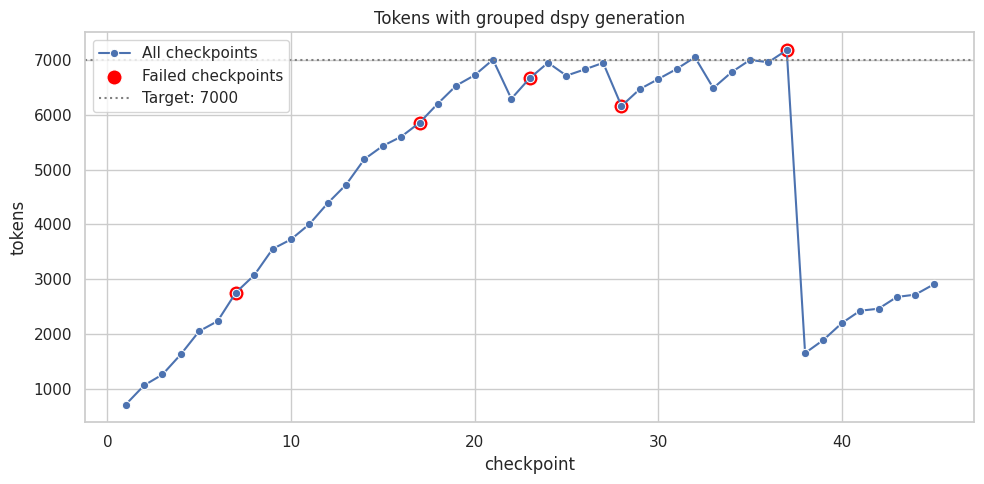

In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

log_path = Path("output/character-profile/uno/v5/processing_log.jsonl")
df = pd.read_json(log_path, lines=True)

plot_df = df[["checkpoint", "tokens_after", "success"]].dropna(
    subset=["checkpoint", "tokens_after"]
)
failed_df = plot_df[~plot_df["success"]]

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))
ax = sns.lineplot(
    data=plot_df,
    x="checkpoint",
    y="tokens_after",
    marker="o",
    label="All checkpoints",
)
sns.scatterplot(
    data=failed_df,
    x="checkpoint",
    y="tokens_after",
    color="red",
    s=120,
    ax=ax,
    label="Failed checkpoints",
)
ax.axhline(7000, color="gray", linestyle=":", linewidth=1.5, label="Target: 7000")
ax.set_title("Tokens with grouped dspy generation")
ax.set_xlabel("checkpoint")
ax.set_ylabel("tokens")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

In [19]:
f"failed {failed_df.shape[0]} out of {plot_df.shape[0]} checkpoints"

'failed 5 out of 45 checkpoints'

## build_agentic_character_profile

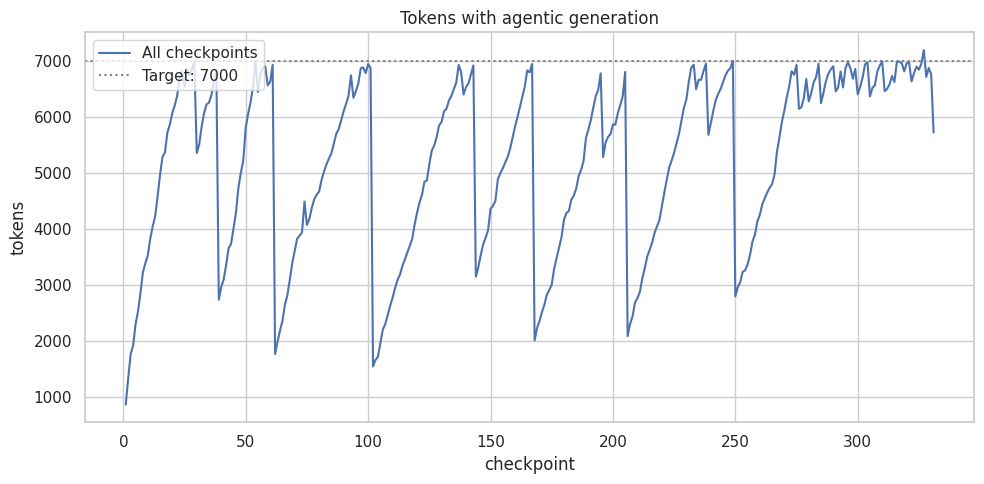

In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

log_path = Path("output/character-profile/uno/v7/processing_log.jsonl")
df = pd.read_json(log_path, lines=True)

plot_df = df[["scene_number", "tokens_after", "success"]].dropna(
    subset=["scene_number", "tokens_after"]
)
failed_df = plot_df[~plot_df["success"]]

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))
ax = sns.lineplot(
    data=plot_df,
    x="scene_number",
    y="tokens_after",
    label="All checkpoints",
)
ax.axhline(7000, color="gray", linestyle=":", linewidth=1.5, label="Target: 7000")
ax.set_title("Tokens with agentic generation")
ax.set_xlabel("checkpoint")
ax.set_ylabel("tokens")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

In [5]:
f"failed {failed_df.shape[0]} out of {plot_df.shape[0]} checkpoints"

'failed 0 out of 331 checkpoints'